# Text Analytics Coursework (Group 37 - Task 2)



# 5) Axis 1-B: LLM-Based Approach (Fine-tuned BERT): 
##### Instead of a general LLM, use a Fine-tuned BioBERT or PubMedBERT LLM Model.


Since the current `gold_label` distribution includes a high proportion of `NONE` and `MIXED` labels, for LLM-Based Approach, we restrict the dataset to unambiguous P/I/O only sentences for the initial experiments. This supports a fair comparison across model axes by reducing label ambiguity that could otherwise blur the distinction between P, I, and O.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sentence_records_df = pd.read_csv("../outputs_SB/sentence_records_df.csv")
sentence_test_records_df = pd.read_csv("../outputs_SB/sentence_test_records_df.csv")

In [4]:
train_pio = sentence_records_df[sentence_records_df["gold_label"].isin(["P","I","O"])].copy()
test_pio  = sentence_test_records_df[sentence_test_records_df["gold_label"].isin(["P","I","O"])].copy()

print(f"Train_PIO_Label_Count: {train_pio["gold_label"].value_counts()}\n")
print(f"Test_PIO_Label_Count: {test_pio["gold_label"].value_counts()}")

Train_PIO_Label_Count: gold_label
O    10669
I     5966
P     2824
Name: count, dtype: int64

Test_PIO_Label_Count: gold_label
O    431
I    289
P    126
Name: count, dtype: int64


In [4]:
train_texts = train_pio["sentence_text"].tolist().copy()
train_labels = train_pio["gold_label"].tolist().copy()

test_texts = test_pio["sentence_text"].tolist().copy()
test_labels = test_pio["gold_label"].tolist().copy()

In [5]:
train_texts[:5]

['The drug combination and administration periods in the PPI group were LPZ 30 mg, CAM 400 mg, MTZ 500 mg (LCM group).',
 'The ranitidine group received RNT 300 mg, CAM 400 mg, MTZ 500 mg (RCM group).',
 'Pre-operative short-term pulmonary rehabilitation for patients of chronic obstructive pulmonary disease undergoing coronary artery bypass graft surgery.',
 'The role of pre-operative short-term pulmonary rehabilitation in patients with chronic obstructive pulmonary disease who undergo coronary artery bypass graft surgery has been assessed for the first time prospectively.',
 'Pre-operative and post-operative peak expiratory flow rate, inspiratory capacity, post-operative ventilation time, post-operative pulmonary complication and hospital stay were determined in both the groups.']

In [6]:
train_labels[:5]

['I', 'I', 'I', 'I', 'O']

#### A) Embedding labels with unsupervised models

In [7]:
import torch, numpy as np
from transformers import AutoTokenizer, AutoModel

def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    return (last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

@torch.no_grad()
def encode_sentences(sentences, model_name, batch_size=32, max_length=128):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device).eval()

    vecs = []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]
        enc = tok(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(device)
        out = model(**enc)
        emb = mean_pool(out.last_hidden_state, enc["attention_mask"])
        vecs.append(emb.cpu().numpy())
    return np.vstack(vecs)

MODELS = {
    "BERT": "bert-base-uncased",
    "BioBERT": "dmis-lab/biobert-base-cased-v1.2",
    "PubMedBERT": "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract",
    "ModernBERT": "answerdotai/ModernBERT-base",
    "BioClinical_ModernBERT": "thomas-sounack/BioClinical-ModernBERT-base",
}

In [ ]:
import os, numpy as np

os.makedirs("./outputs_SB/embeddings_axis1B", exist_ok=True)

def encode_and_save(sentences, tag, model_name, split_name, batch_size=16, max_length=128):
    out_path = f"embeddings_axis1B/{split_name}_{tag}_meanpool.npy"
    if os.path.exists(out_path):
        print("Already exists, skipping:", out_path)
        return np.load(out_path)

    X = encode_sentences(sentences, model_name, batch_size=batch_size, max_length=max_length)
    np.save(out_path, X)
    print("Saved:", out_path, X.shape)
    return X

X_bert = encode_and_save(train_texts, "BERT", MODELS["BERT"], "train_pio", batch_size=16, max_length=64)

Already exists, skipping: embeddings_axis1B/train_pio_BERT_meanpool.npy


In [9]:
X_pub = encode_and_save(train_texts, "PubMedBERT", MODELS["PubMedBERT"], "train_pio", batch_size=16, max_length=64)

Already exists, skipping: embeddings_axis1B/train_pio_PubMedBERT_meanpool.npy


In [10]:
X_bio = encode_and_save(train_texts, "BioBERT", MODELS["BioBERT"], "train_pio", batch_size=16, max_length=64)

Already exists, skipping: embeddings_axis1B/train_pio_BioBERT_meanpool.npy


In [11]:
X_mod_bert = encode_and_save(train_texts, "ModernBERT", MODELS["ModernBERT"], "train_pio", batch_size=16, max_length=64)

Already exists, skipping: embeddings_axis1B/train_pio_ModernBERT_meanpool.npy


In [12]:
X_biocli_mod_bert = encode_and_save(train_texts, "BioClinical_ModernBERT", MODELS["BioClinical_ModernBERT"], "train_pio", batch_size=16, max_length=64)

Already exists, skipping: embeddings_axis1B/train_pio_BioClinical_ModernBERT_meanpool.npy


In [13]:
import numpy as np
X_bert = np.load("embeddings_axis1B/train_pio_BERT_meanpool.npy")
X_pub  = np.load("embeddings_axis1B/train_pio_PubMedBERT_meanpool.npy")
X_bio  = np.load("embeddings_axis1B/train_pio_BioBERT_meanpool.npy")
X_mod_bert  = np.load("embeddings_axis1B/train_pio_ModernBERT_meanpool.npy")
X_biocli_mod_bert  = np.load("embeddings_axis1B/train_pio_BioClinical_ModernBERT_meanpool.npy")

print(X_bert.shape, X_pub.shape, X_bio.shape, X_mod_bert.shape, X_biocli_mod_bert.shape )

(19459, 768) (19459, 768) (19459, 768) (19459, 768) (19459, 768)


#### B) Clustering evaluation function for P/I/O only labels dataframe

In [14]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, normalized_mutual_info_score
from sklearn.preprocessing import LabelEncoder

def clustering_evaluation(df_pio, X, name="MODEL", k=3, seed=42, hac_sample=1000):

    # Embedding gold labels
    le = LabelEncoder()
    embedded_y = le.fit_transform(df_pio["gold_label"].values)

    # KMeans
    kmeans = KMeans(n_clusters=k, random_state=seed, n_init=10)
    kmeans_clusters = kmeans.fit_predict(X)
    kmeans_silhouette = silhouette_score(X, kmeans_clusters)
    kmeans_nmi = normalized_mutual_info_score(embedded_y, kmeans_clusters)

    # HAC
    np.random.seed(seed)
    sample_index = np.random.choice(len(df_pio), min(hac_sample, len(df_pio)), replace=False)
    Xs = X[sample_index]
    ys = embedded_y[sample_index]

    hac = AgglomerativeClustering(n_clusters=k, linkage="ward")
    hac_clusters = hac.fit_predict(Xs)
    hac_silhouette = silhouette_score(Xs, hac_clusters)
    hac_nmi = normalized_mutual_info_score(ys, hac_clusters)

    # contingency tables
    kmeans_contingency = pd.crosstab(pd.Series(df_pio["gold_label"], name="gold_label"),
                        pd.Series(kmeans_clusters, name="cluster"))
    
    labels_sample = df_pio.iloc[sample_index]["gold_label"].to_numpy()
    hac_contingency = pd.crosstab(pd.Series(labels_sample, name="gold_label"),
                        pd.Series(hac_clusters, name="cluster"))



    print(f"\n===========================================")
    print(f"P/I/O only results: {name} (K={k})")
    print(f"===========================================\n")
    print(f"==== KMeans ====\n Normalized Mutual Information(NMI): {kmeans_nmi:.4f}\n Silhouette score: {kmeans_silhouette:.4f}\n")
    print("KMeans contingency table:\n", kmeans_contingency)
    print(f"\n==== HAC(sample={len(sample_index)}) ====\n Normalized Mutual Information(NMI): {hac_nmi:.4f}\n Silhouette score: {hac_silhouette:.4f}\n")
    print("HAC contingency table:\n", hac_contingency)

    return {
        "Model": name,
        "KMeans_Silhouette": kmeans_silhouette,
        "KMeans_NMI": kmeans_nmi,
        "HAC_Silhouette": hac_silhouette,
        "HAC_NMI": hac_nmi,
        "KMeans_Contingency_Tables": kmeans_contingency,
        "HAC_Contingency_Tables": hac_contingency
    }

In [15]:
result_bert = clustering_evaluation(train_pio, X_bert, name="BERT", k=3)
result_pub  = clustering_evaluation(train_pio, X_pub,  name="PubMedBERT", k=3)
result_bio  = clustering_evaluation(train_pio, X_bio,  name="BioBERT", k=3)
result_mod_bert  = clustering_evaluation(train_pio, X_mod_bert,  name="ModernBERT", k=3)
result_biocli_mod_bert  = clustering_evaluation(train_pio, X_biocli_mod_bert, name="BioClinical_ModernBERT", k=3)


P/I/O only results: BERT (K=3)

==== KMeans ====
 Normalized Mutual Information(NMI): 0.0476
 Silhouette score: 0.0395

KMeans contingency table:
 cluster        0     1     2
gold_label                  
I           1127   702  1100
O           1959  1262  1989
P            442   328   504

==== HAC(sample=1000) ====
 Normalized Mutual Information(NMI): 0.0727
 Silhouette score: 0.0403

HAC contingency table:
 cluster       0    1   2
gold_label              
I            66  182  71
O           301  140  96
P            57   29  58

P/I/O only results: PubMedBERT (K=3)

==== KMeans ====
 Normalized Mutual Information(NMI): 0.0159
 Silhouette score: 0.0696

KMeans contingency table:
 cluster        0     1     2
gold_label                  
I            652   892  1385
O           1119  1645  2446
P            315   367   592

==== HAC(sample=1000) ====
 Normalized Mutual Information(NMI): 0.0318
 Silhouette score: 0.0556

HAC contingency table:
 cluster       0   1    2
gold_label  

In [16]:
import pandas as pd

results = [result_bert, result_pub, result_bio, result_mod_bert, result_biocli_mod_bert]

def result_summary(result):
    
    return {
        "Model": result.get("Model", result.get("name", "unknown")),
        # KMeans
        "KMeans_NMI": result.get("KMeans_NMI"),
        "KMeans_Silhouette": result.get("KMeans_Silhouette"),
        # HAC
        "HAC_NMI": result.get("HAC_NMI"),
        "HAC_silhouette": result.get("HAC_Silhouette"),
    }

summary_df = pd.DataFrame([result_summary(result) for result in results])
summary_df = summary_df.sort_values(by="KMeans_NMI", ascending=False).round(4)

summary_df

,Model,KMeans_NMI,KMeans_Silhouette,HAC_NMI,HAC_silhouette
2,BioBERT,0.1013,0.0455,0.1475,0.0391
4,BioClinical_ModernBERT,0.0921,0.0459,0.1109,0.0332
0,BERT,0.0476,0.0395,0.0727,0.0403
3,ModernBERT,0.0335,0.0590,0.0305,0.0463
1,PubMedBERT,0.0159,0.0696,0.0318,0.0556


We report NMI as the primary metric for cluster–label correspondence (P/I/O), with silhouette as a secondary geometric diagnostic.

KMeans (NMI): BioBERT (0.1003) > BioClinical_ModernBERT (0.0921) > BERT (0.0476) > ModernBERT (0.0335) > PubMedBERT (0.0159).
HAC (sample=1000) shows a similar trend with BioBERT (0.1475) and BioClinical_ModernBERT (0.1109) achieving the strongest label alignment, while BERT being moderate (0.0727) and PubMedBERT/ModernBERT being low (0.03).

PubMedBERT has the highest silhouette (KMeans 0.0696) but the lowest NMI. This indicates that clusters are well-separated geometrically but do not align well with the P/I/O schema. Furthermore, contingency tables show clusters for all models, with "Outcomes" generally dominating counts and "Participants" being the smallest.

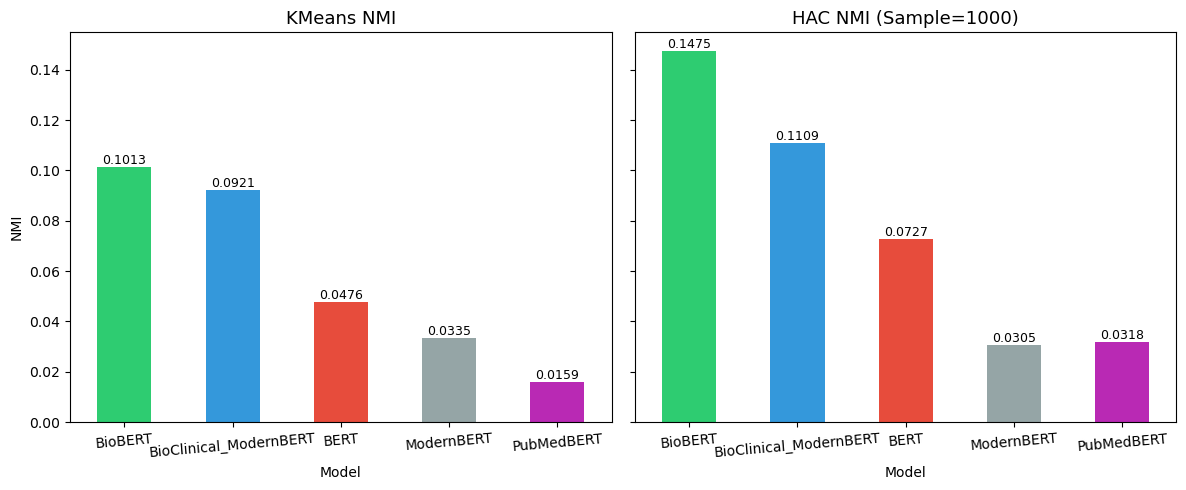

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# KMeans plot
summary_df.set_index("Model")["KMeans_NMI"].plot(kind="bar",ax=axes[0], color=["#2ecc71", "#3498db", "#e74c3c", "#95a5a6",  "#b929b4"])
axes[0].set_title("KMeans NMI", fontsize=13)
axes[0].set_xlabel("Model")
axes[0].set_ylabel("NMI")
axes[0].tick_params(axis="x", rotation=5)

for i in axes[0].containers:
    axes[0].bar_label(i, fontsize=9)

# HAC plot
summary_df.set_index("Model")["HAC_NMI"].plot(kind="bar",ax=axes[1], color=["#2ecc71", "#3498db", "#e74c3c", "#95a5a6",  "#b929b4"])
axes[1].set_title("HAC NMI (Sample=1000)", fontsize=13)
axes[1].set_xlabel("Model")
axes[1].set_ylabel("NMI")
axes[1].tick_params(axis="x", rotation=5)

for i in axes[1].containers:
    axes[1].bar_label(i, fontsize=9)

plt.tight_layout()
plt.show()

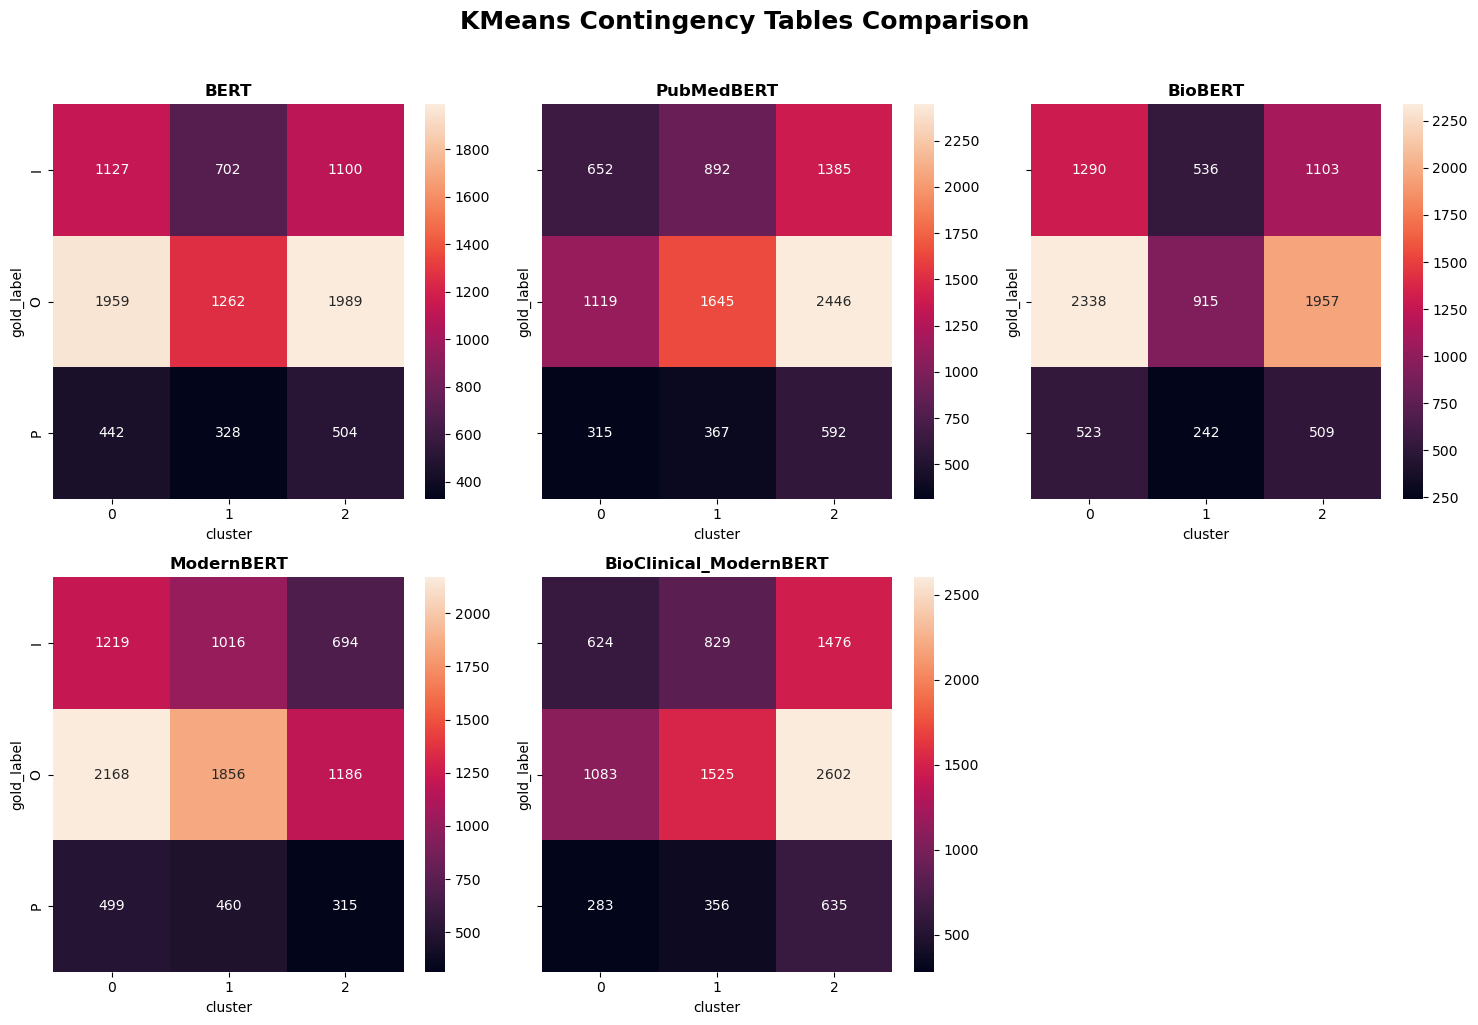

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15,10), sharey=True)
fig.suptitle("KMeans Contingency Tables Comparison", fontsize=18, fontweight='bold', y=1.02)
axes = axes.flatten()

sns.heatmap(result_bert["KMeans_Contingency_Tables"], annot=True, fmt="d", ax=axes[0])
axes[0].set_title("BERT",fontweight='bold')

sns.heatmap(result_pub["KMeans_Contingency_Tables"], annot=True, fmt="d", ax=axes[1])
axes[1].set_title("PubMedBERT",fontweight='bold')

sns.heatmap(result_bio["KMeans_Contingency_Tables"], annot=True, fmt="d", ax=axes[2])
axes[2].set_title("BioBERT",fontweight='bold')

sns.heatmap(result_mod_bert["KMeans_Contingency_Tables"], annot=True, fmt="d", ax=axes[3])
axes[3].set_title("ModernBERT",fontweight='bold')

sns.heatmap(result_biocli_mod_bert["KMeans_Contingency_Tables"], annot=True, fmt="d", ax=axes[4])
axes[4].set_title("BioClinical_ModernBERT",fontweight='bold')

axes[5].axis('off')

plt.tight_layout()
plt.show()


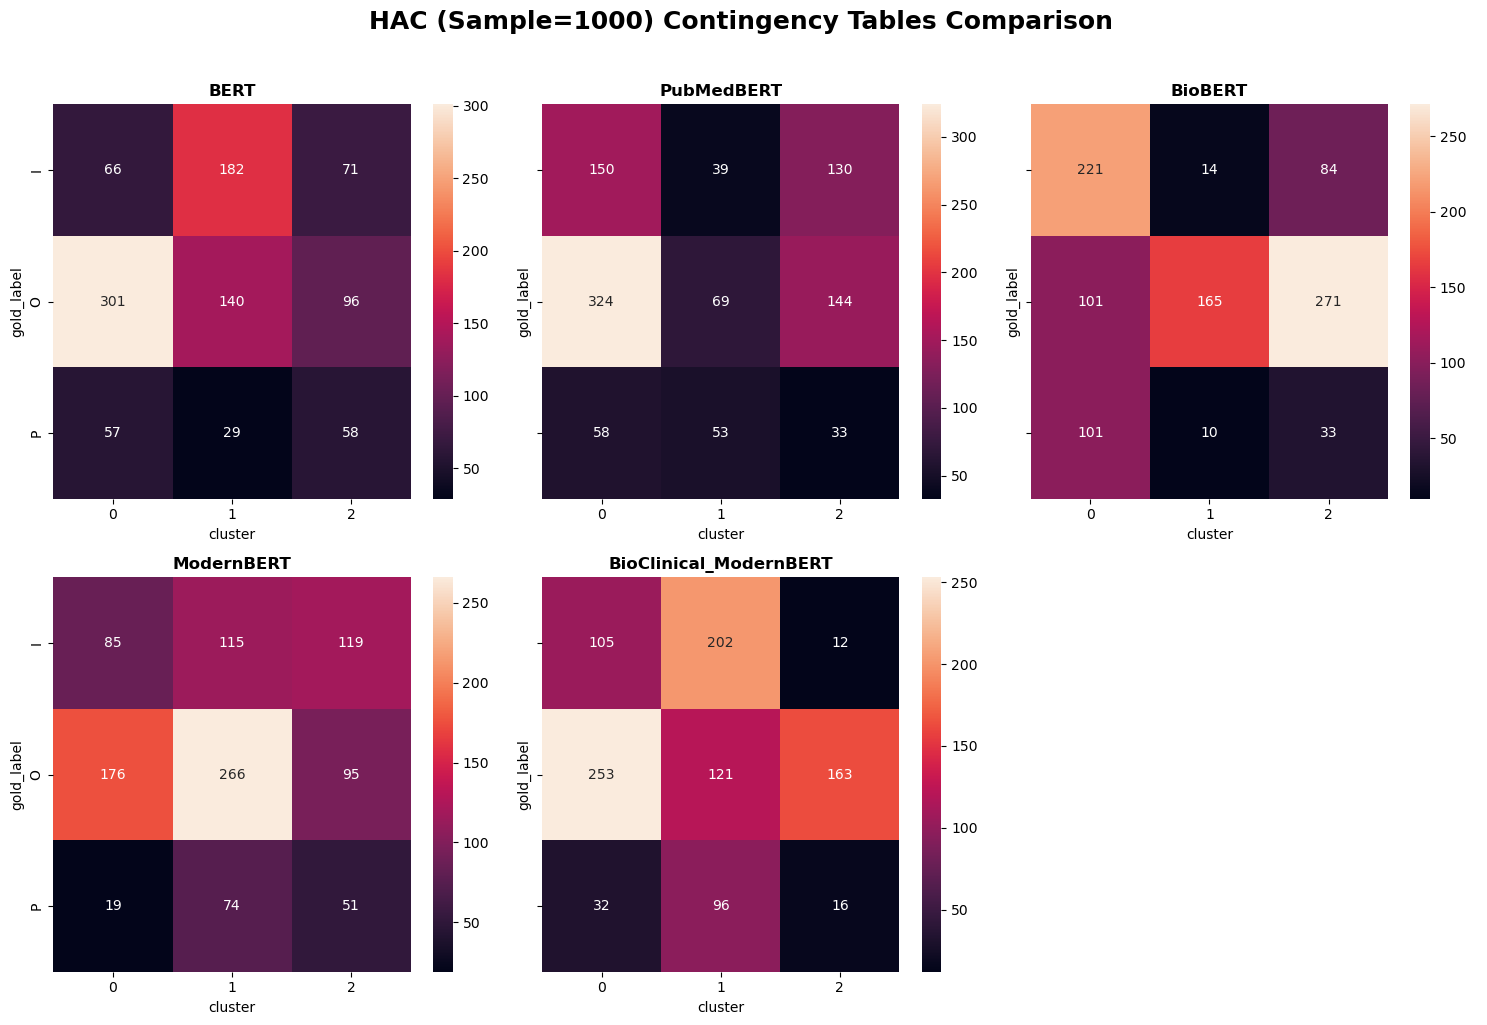

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15,10), sharey=True)
fig.suptitle("HAC (Sample=1000) Contingency Tables Comparison ", fontsize=18, fontweight='bold', y=1.02)
axes = axes.flatten()

sns.heatmap(result_bert["HAC_Contingency_Tables"], annot=True, fmt="d", ax=axes[0])
axes[0].set_title("BERT",fontweight='bold')

sns.heatmap(result_pub["HAC_Contingency_Tables"], annot=True, fmt="d", ax=axes[1])
axes[1].set_title("PubMedBERT",fontweight='bold')

sns.heatmap(result_bio["HAC_Contingency_Tables"], annot=True, fmt="d", ax=axes[2])
axes[2].set_title("BioBERT",fontweight='bold')

sns.heatmap(result_mod_bert["HAC_Contingency_Tables"], annot=True, fmt="d", ax=axes[3])
axes[3].set_title("ModernBERT",fontweight='bold')

sns.heatmap(result_biocli_mod_bert["HAC_Contingency_Tables"], annot=True, fmt="d", ax=axes[4])
axes[4].set_title("BioClinical_ModernBERT",fontweight='bold')

axes[5].axis('off')

plt.tight_layout()
plt.show()


Even with domain specific encoders (BioBERT,PubMedBERT BioClinical ModernBERT), clusters are not clearly separated by P/I/O. This is expected because P/I/O labels reflect the role of a sentence (participant/intervention/outcome) rather than topical similarity, and sentence embeddings tend to organize texts primarily by semantic topic and writing style. As a result, large mixed clusters emerge, especially under class imbalance (Outcomes dominating and Participants being sparse). This motivates moving from unsupervised clustering to task-specific fine-tuning for more reliable P/I/O discrimination.

#### C) Embedding labels with supervised models (Fine-Tuned BioBERT and PubMedBERT)

In [20]:
#### C) Embedding labels with supervised models (Fine-Tuned)

# !pip install evaluate
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
import evaluate

# Prepare P/I/O dataset
train_df = train_pio[["sentence_text", "gold_label"]].copy()
test_df  = test_pio[["sentence_text", "gold_label"]].copy()

le = LabelEncoder()
train_df["label_id"] = le.fit_transform(train_df["gold_label"])
test_df["label_id"]  = le.transform(test_df["gold_label"])

X_train, X_val, y_train, y_val = train_test_split(
    train_df["sentence_text"].tolist(),
    train_df["label_id"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=train_df["label_id"],
)

X_test = test_df["sentence_text"].tolist()
y_test = test_df["label_id"].tolist()

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print("Sizes:", len(X_train), len(X_val), len(X_test))

# Fine-Tuning Models
MODELS_FT = {
    "BioBERT": "dmis-lab/biobert-base-cased-v1.2",
    "PubMedBERT": "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract",
}

# Metrics
acc = evaluate.load("accuracy")
f1  = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": acc.compute(predictions=preds, references=labels)["accuracy"],
        "macro_f1": f1.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

def make_datasets(tokenizer, max_len=64):
    train_dataset = Dataset.from_dict({"text": X_train, "labels": y_train})
    val_dataset   = Dataset.from_dict({"text": X_val,   "labels": y_val})
    test_dataset  = Dataset.from_dict({"text": X_test,  "labels": y_test})

    def tokenize(batch):
        return tokenizer(batch["text"], truncation=True, padding="max_length", max_len=64)

    train_dataset = train_dataset.map(tokenize, batched=True)
    val_dataset   = val_dataset.map(tokenize, batched=True)
    test_dataset  = test_dataset.map(tokenize, batched=True)

    cols = ["input_ids", "attention_mask", "labels"]
    train_dataset.set_format(type="torch", columns=cols)
    val_dataset.set_format(type="torch", columns=cols)
    test_dataset.set_format(type="torch", columns=cols)
    return train_dataset, val_dataset, test_dataset


Label mapping: {'I': np.int64(0), 'O': np.int64(1), 'P': np.int64(2)}
Sizes: 15567 3892 846


In [47]:
import os
import torch

from transformers.trainer_utils import get_last_checkpoint
from datasets import disable_progress_bar
disable_progress_bar()

os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

if torch.backends.mps.is_available():
    torch.mps.empty_cache()

os.makedirs("finetune_axis1B", exist_ok=True)
all_results = []

def run_finetuning(tag, verbose=True):
    model_name = MODELS_FT[tag]
    output_dir = f"finetune_axis1B/{tag}"

    print("\n===========================================")
    print("P/I/O only Fine-tuning results:", tag)
    print("===========================================")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    # Create or check for existing dataset
    train_dataset, val_dataset, test_dataset = make_datasets(tokenizer, max_len=64)

    last_checkpoint = get_last_checkpoint(output_dir)
    is_trained = last_checkpoint is not None or os.path.exists(os.path.join(output_dir, "config.json"))

    if is_trained:
        load_path = last_checkpoint if last_checkpoint else output_dir
        model = AutoModelForSequenceClassification.from_pretrained(load_path)

# Fine-tune with Trainer
    else:
        model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(le.classes_))

    args = TrainingArguments(
        output_dir=f"finetune_axis1B/{tag}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=2,
        gradient_checkpointing=True,
        num_train_epochs=2,
        weight_decay=0.01,
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        save_total_limit=1, 
        dataloader_pin_memory=False,
        disable_tqdm=True,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
    )

    if not is_trained:
        trainer.train()
        trainer.save_model(output_dir)
        
# Evaluate on test set
    test_metrics = trainer.evaluate(test_dataset)

    if verbose:
            print("Test metrics:", test_metrics)

    result = {"Model": tag, **test_metrics}
    all_results.append(result)

    return trainer, test_dataset, result

In [51]:
all_results = []
trainer_bio, test_dataset_bio, result_ft_bio = run_finetuning("BioBERT",verbose=False)


P/I/O only Fine-tuning results: BioBERT


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{'eval_loss': '0.4513', 'eval_model_preparation_time': '0.001', 'eval_accuracy': '0.8664', 'eval_macro_f1': '0.8612', 'eval_runtime': '5.347', 'eval_samples_per_second': '158.2', 'eval_steps_per_second': '39.65'}


In [52]:
trainer_pub, test_dataset_pub, result_ft_pub = run_finetuning("PubMedBERT", verbose=False)


P/I/O only Fine-tuning results: PubMedBERT


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{'eval_loss': '0.4371', 'eval_model_preparation_time': '0.0011', 'eval_accuracy': '0.8818', 'eval_macro_f1': '0.8752', 'eval_runtime': '4.576', 'eval_samples_per_second': '184.9', 'eval_steps_per_second': '46.33'}


In [ ]:
# summary table
summary_df = pd.DataFrame(all_results)[
    ["Model", "eval_loss", "eval_accuracy", "eval_macro_f1"] # Runtime-related values in this table reflect test-set evaluation time after loading saved checkpoints, rather than full training time. Therefore, they are not used for the main comparison of model efficiency.
].rename(columns={
    "eval_loss": "Loss",
    "eval_accuracy": "Accuracy",
    "eval_macro_f1": "Macro-F1"
})
summary_df

,Model,Loss,Accuracy,Macro-F1
0,BioBERT,0.451281,0.866430,0.861206
1,PubMedBERT,0.437083,0.881797,0.875216


In [45]:
# Classification report and Confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

pred = trainer_pub.predict(test_dataset_pub)
y_pred = np.argmax(pred.predictions, axis=-1)

print("\nClassification report for BioBERT:")
print(classification_report(pred.label_ids, y_pred, target_names=le.classes_))

print("\nConfusion matrix for BioBERT:")
print(confusion_matrix(pred.label_ids, y_pred))

pred = trainer_bio.predict(test_dataset_bio)
y_pred = np.argmax(pred.predictions, axis=-1)

print("\n\n\nClassification report for PubMedBERT:")
print(classification_report(pred.label_ids, y_pred, target_names=le.classes_))
print("\nConfusion matrix for PubMedBERT:")
print(confusion_matrix(pred.label_ids, y_pred))


Classification report for BioBERT:
              precision    recall  f1-score   support

           I       0.91      0.78      0.84       289
           O       0.87      0.95      0.91       431
           P       0.86      0.90      0.88       126

    accuracy                           0.88       846
   macro avg       0.88      0.87      0.88       846
weighted avg       0.88      0.88      0.88       846


Confusion matrix for BioBERT:
[[224  53  12]
 [ 16 409   6]
 [  6   7 113]]



Classification report for PubMedBERT:
              precision    recall  f1-score   support

           I       0.87      0.78      0.82       289
           O       0.87      0.92      0.89       431
           P       0.87      0.87      0.87       126

    accuracy                           0.87       846
   macro avg       0.87      0.86      0.86       846
weighted avg       0.87      0.87      0.87       846


Confusion matrix for PubMedBERT:
[[225  55   9]
 [ 25 398   8]
 [ 10   6 110]]
